In [1]:
from sklearn import tree
import graphviz
import matplotlib.pyplot as plt
from sklearn import datasets
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [2]:
iris = datasets.load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Categorical.from_codes(iris.target, iris.target_names)

In [3]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
y

['setosa', 'setosa', 'setosa', 'setosa', 'setosa', ..., 'virginica', 'virginica', 'virginica', 'virginica', 'virginica']
Length: 150
Categories (3, object): ['setosa', 'versicolor', 'virginica']

In [5]:
y = pd.get_dummies(y)
y.head()

,setosa,versicolor,virginica
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False


In [6]:
x_train, X_test, y_train, y_test = train = train_test_split(X, y, random_state=1)

In [7]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

DecisionTreeClassifier()

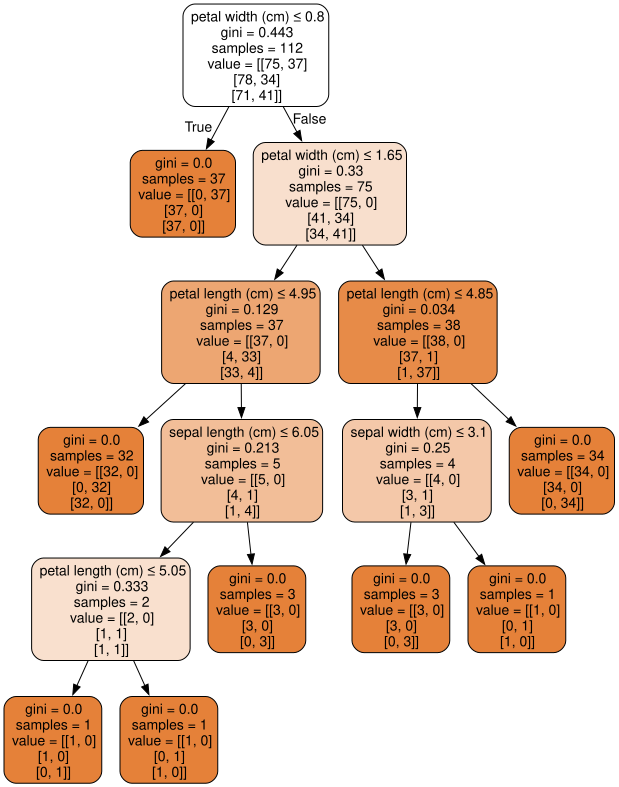

In [8]:
dot_data = tree.export_graphviz(dt,
                                feature_names=iris.feature_names,
                                class_names=iris.target_names,
                                filled=True, rounded=True,
                                special_characters=True)

graph = graphviz.Source(dot_data)
graph

In [9]:
y_pred = dt.predict(X_test)
y_pred

array([[ True, False, False],
       [False,  True, False],
       [False,  True, False],
       [ True, False, False],
       [False, False,  True],
       [False,  True, False],
       [False, False,  True],
       [ True, False, False],
       [ True, False, False],
       [False, False,  True],
       [False,  True, False],
       [ True, False, False],
       [False, False,  True],
       [False,  True, False],
       [False,  True, False],
       [ True, False, False],
       [False,  True, False],
       [False,  True, False],
       [ True, False, False],
       [ True, False, False],
       [False,  True, False],
       [False,  True, False],
       [False, False,  True],
       [ True, False, False],
       [False, False,  True],
       [False,  True, False],
       [ True, False, False],
       [ True, False, False],
       [False,  True, False],
       [False, False,  True],
       [False,  True, False],
       [False, False,  True],
       [False,  True, False],
       [Fa

In [10]:
species = np.array(y_test).argmax(axis=1)
predictions = np.array(y_pred).argmax(axis=1)

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(confusion_matrix(species, predictions))
print(classification_report(species, predictions))
print('akurasi :', accuracy_score(species, predictions))

[[13  0  0]
 [ 0 15  1]
 [ 0  0  9]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      0.94      0.97        16
           2       0.90      1.00      0.95         9

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38

akurasi : 0.9736842105263158


# Post test

In [12]:
data_stress = pd.read_csv(r'D:\Semester 5\Penambangan Data\Praktikum\Student_Stress_Factors.csv')

In [13]:
data_stress.head()

,Kindly Rate your Sleep Quality 😴,How many times a week do you suffer headaches 🤕?,How would you rate you academic performance 👩‍🎓?,how would you rate your study load?,How many times a week you practice extracurricular activities 🎾?,How would you rate your stress levels?
0,3,1,3,4,2,3
1,4,1,2,3,3,2
2,2,1,2,1,4,4
3,3,2,3,2,3,3
4,2,3,1,5,5,3


In [14]:
# 2. Siapkan Data (X dan y)
# ===============================
# Target: "How would you rate your stress levels?"
X = data_stress.drop(columns=["How would you rate your stress levels?"])
y = data_stress["How would you rate your stress levels?"]

In [15]:
# Ubah target menjadi one-hot encoding
y = pd.get_dummies(y)

In [16]:
# Tampilkan 5 data teratas dari Y
y

,1,2,3,4,5
0,False,False,True,False,False
1,False,True,False,False,False
2,False,False,False,True,False
3,False,False,True,False,False
4,False,False,True,False,False
...,...,...,...,...,...
515,True,False,False,False,False
516,False,True,False,False,False
517,False,True,False,False,False
518,False,False,False,False,True


In [17]:
# 3. Split data (train-test)
x_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [18]:
# 4. Train Decision Tree
data_stress = DecisionTreeClassifier()
data_stress.fit(x_train, y_train)

DecisionTreeClassifier()

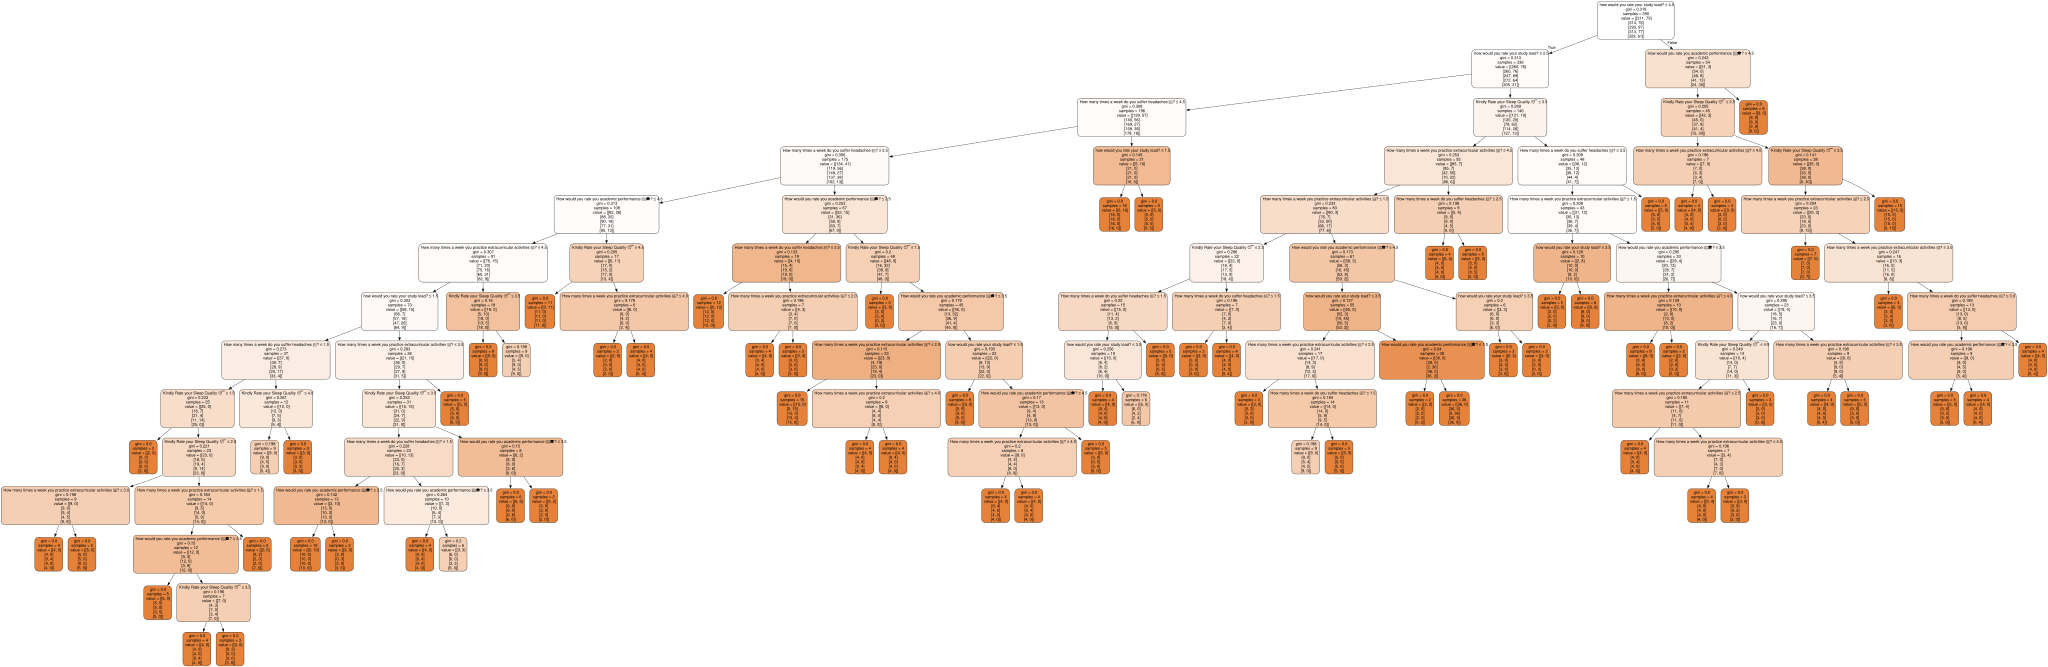

In [19]:
# 5. Visualisasi Decision Tree
dot_data = tree.export_graphviz(
    data_stress,
    feature_names=X.columns,
    class_names=[str(c) for c in y.columns],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph 

In [20]:
# 6. Prediksi
y_pred = data_stress.predict(X_test)

In [21]:
# Konversi one-hot ke label angka
species = np.array(y_test).argmax(axis=1)
predictions = np.array(y_pred).argmax(axis=1)

In [22]:
# 7. Evaluasi Model
print(confusion_matrix(species, predictions))
print(classification_report(species, predictions))
print("akurasi:", accuracy_score(species, predictions))

[[31  0  0  0  0]
 [ 0 28  0  1  0]
 [ 0  0 24  4  0]
 [ 2  0  0 21  0]
 [ 0  0  1  0 18]]
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        31
           1       1.00      0.97      0.98        29
           2       0.96      0.86      0.91        28
           3       0.81      0.91      0.86        23
           4       1.00      0.95      0.97        19

    accuracy                           0.94       130
   macro avg       0.94      0.94      0.94       130
weighted avg       0.94      0.94      0.94       130

akurasi: 0.9384615384615385


# WINE QUALITY

In [11]:
from sklearn import tree
import graphviz
import matplotlib.pyplot as plt
from sklearn import datasets
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [12]:
data_wine = pd.read_csv(r'D:\Semester 5\Penambangan Data\Praktikum\winequality-red.csv')

In [13]:
data_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [14]:
X = data_wine.drop('quality', axis=1)
y = data_wine['quality']

In [15]:
y = pd.get_dummies(y)

In [16]:
y

,3,4,5,6,7,8
0,False,False,True,False,False,False
1,False,False,True,False,False,False
2,False,False,True,False,False,False
3,False,False,False,True,False,False
4,False,False,True,False,False,False
...,...,...,...,...,...,...
1594,False,False,True,False,False,False
1595,False,False,False,True,False,False
1596,False,False,False,True,False,False
1597,False,False,True,False,False,False


In [17]:
X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2


In [18]:
x_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [19]:
data_wine = DecisionTreeClassifier()
data_wine.fit(x_train, y_train)

NameError: name 'DecisionTreeClassifier' is not defined

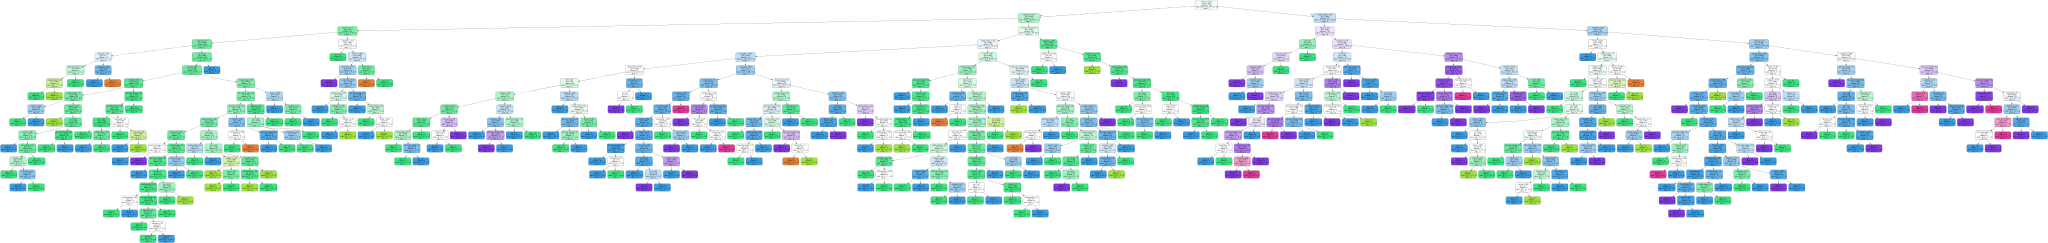

In [76]:
dot_data = tree.export_graphviz(
    data_wine,
    feature_names=X.columns,
    class_names = [str(c) for c in y.unique()],
    filled=True, rounded=True, special_characters=True
)

graph = graphviz.Source(dot_data)
graph

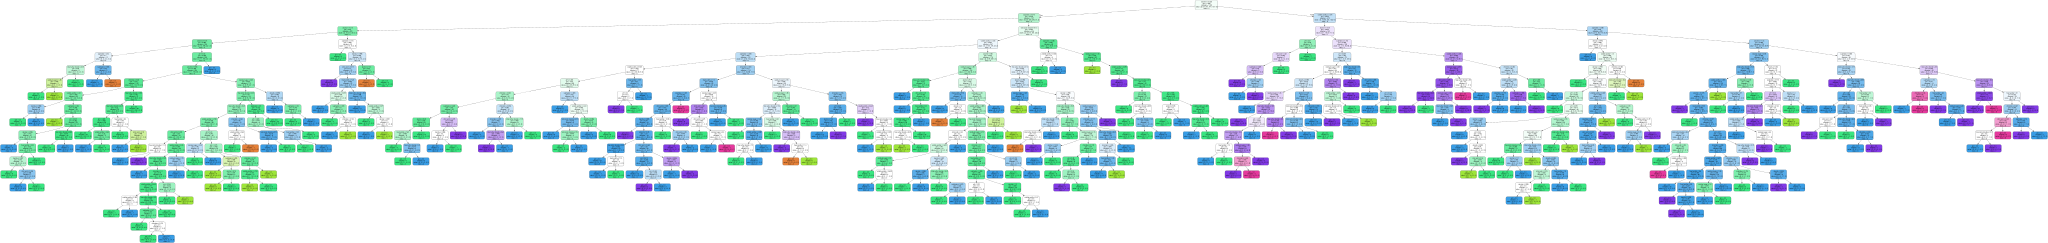

In [77]:
dot_data = tree.export_graphviz(
    data_wine,
    feature_names=X.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph 

In [78]:
y_pred = data_wine.predict(X_test)

In [79]:
species = np.array(y_test) 
predictions = np.array(y_pred)

In [80]:
print(confusion_matrix(species, predictions))
print(classification_report(species, predictions))
print("akurasi:", accuracy_score(species, predictions))

[[  0   0   1   0   0   0]
 [  1   1   9   4   1   0]
 [  1   1 117  48   4   0]
 [  0   0  51  95  18   3]
 [  0   0   7   9  25   1]
 [  0   0   0   1   1   1]]
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.50      0.06      0.11        16
           5       0.63      0.68      0.66       171
           6       0.61      0.57      0.59       167
           7       0.51      0.60      0.55        42
           8       0.20      0.33      0.25         3

    accuracy                           0.60       400
   macro avg       0.41      0.37      0.36       400
weighted avg       0.60      0.60      0.59       400

akurasi: 0.5975
